In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
from scipy.special import erfc

In [3]:
# Helper functions
def pulse_shape(bits_number, samples_number, bits):
    input_signal = np.ones((bits_number, samples_number))
    for i in range(bits_number):
        if bits[i] == 0:
            input_signal[i, :] = -input_signal[i, :]
    return input_signal

def add_noise(bits_number, samples_number, input_signal, E, snr):
    sigma = np.sqrt(E / (2.0 * snr))
    noise = np.random.normal(0, sigma, (1, bits_number * samples_number))
    input_with_noise = input_signal / np.sqrt(samples_number)

    for i in range(bits_number):
        input_with_noise[i, :] += noise[0, samples_number * i : samples_number * (i + 1)]

    return input_with_noise.reshape(-1, 1)

In [4]:
def sample(output, bits_number, samples_number):
    samples = np.ones(bits_number)
    for i in range(bits_number):
        samples[i] = output[(samples_number - 1) + samples_number * i] > 0
        return samples


# Parameters

samples_number = 50
bits = np.array([0, 1, 1, 0, 1, 1, 0, 1])
bits_number = len(bits)
E = 1
snr_range = np.arange(-10, 21, 1)
snr = 10 ** (10 / 10)

input_signal = pulse_shape(bits_number, samples_number, bits)
s = input_signal.reshape(-1, 1)
recieved_signal = add_noise(bits_number, samples_number, input_signal, E, snr)

# Define filters
matched_filter = np.ones(samples_number)
impulse_response_filter = np.zeros(samples_number)
impulse_response_filter[samples_number // 2] = 1
tri_filter = (np.sqrt(3) / samples_number) * np.arange(samples_number)
filters = [matched_filter, impulse_response_filter, tri_filter]
outputs = []

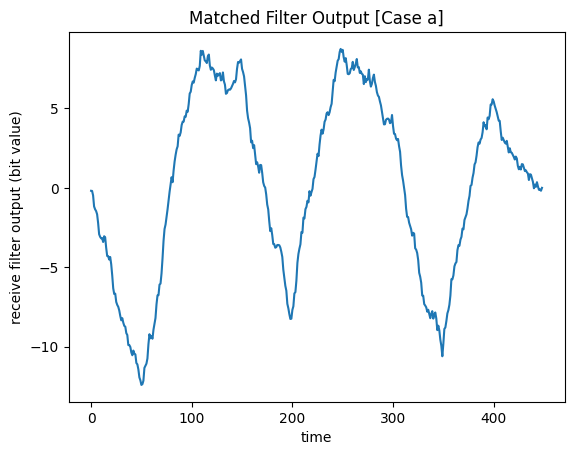

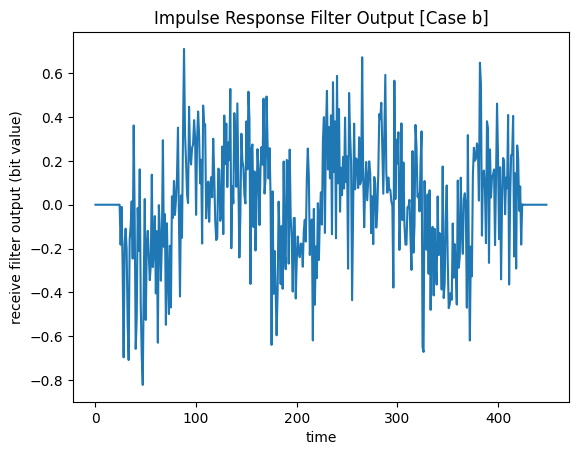

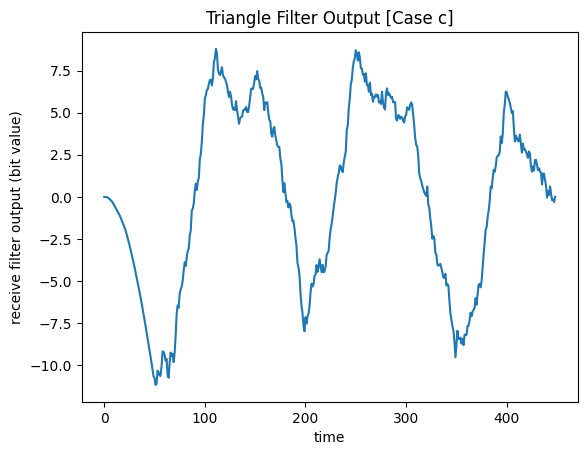

In [5]:
# Apply filters
for filter in filters:
    outputs.append(convolve(recieved_signal.flatten(), filter))

# Plot filter outputs
titles = [
    "Matched Filter Output [Case a]",
    "Impulse Response Filter Output [Case b]",
    "Triangle Filter Output [Case c]",
]

for output, title in zip(outputs, titles):
    plt.figure()
    plt.plot(output)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("receive filter output (bit value)")
    plt.savefig(f"{title}.png")
    plt.show()

# BER vs SNR simulation
bits_number = 100000
bits = np.ones(bits_number)
indices = np.random.permutation(bits_number)[:1]
bits[indices] = 0
s = pulse_shape(bits_number, samples_number, bits)
BER_sim = np.zeros((3, len(snr_range)))
BER_theo = np.zeros((3, len(snr_range)))

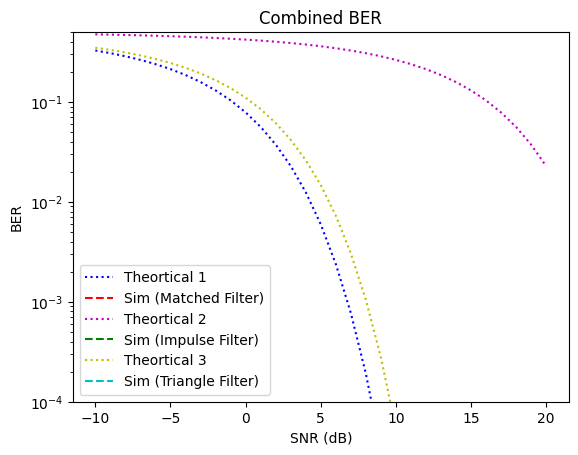

In [6]:
for i, snr_db in enumerate(snr_range):
    snr = 10 ** (snr_db / 10)
    recieved_signal = add_noise(bits_number, samples_number, s, E, snr)
    for k, f in enumerate(filters):
        output = convolve(recieved_signal.flatten(), f)
        output_samples = sample(output, bits_number, samples_number)

    BER_sim[k, i] = np.sum(output_samples != bits) / bits_number
    BER_theo[0, i] = 0.5 * erfc(np.sqrt(snr))
    BER_theo[1, i] = 0.5 * erfc(np.sqrt(snr / samples_number))
    BER_theo[2, i] = 0.5 * erfc((np.sqrt(3) / 2) * np.sqrt(snr))

# Plot combined BER
plt.figure()
plt.semilogy(snr_range, BER_theo[0], "b:", label="Theortical 1")
plt.semilogy(snr_range, BER_sim[0], "r--", label="Sim (Matched Filter)")
plt.semilogy(snr_range, BER_theo[1], "m:", label="Theortical 2")
plt.semilogy(snr_range, BER_sim[1], "g--", label="Sim (Impulse Filter)")
plt.semilogy(snr_range, BER_theo[2], "y:", label="Theortical 3")
plt.semilogy(snr_range, BER_sim[2], "c--", label="Sim (Triangle Filter)")
plt.ylim(1e-4, 0.5)
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.legend()
plt.title("Combined BER")
plt.savefig("combined_ber.png")
plt.show()